# RQ1 plots from saved audited outputs

This notebook reads existing CSV results only. It does not load tokenizers or transformer models and does not rerun RQ1/RQ2 experiments.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("analysis_outputs_audited")
FIG_DIR = Path("figures_rq1_from_saved_outputs")
FIG_DIR.mkdir(exist_ok=True)

required = {
    "per_sentence": DATA_DIR / "rq1_per_sentence_tokenization.csv",
    "summary": DATA_DIR / "rq1_summary_tokenizers.csv",
    "by_source": DATA_DIR / "rq1_summary_by_source.csv",
    "vocab": DATA_DIR / "rq1_vocab_overlap_by_source.csv",
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing saved RQ1 files. Run this notebook with CWD set to the backup folder. "
        f"Missing: {missing}"
    )

df = pd.read_csv(required["per_sentence"])
summary = pd.read_csv(required["summary"])
summary_by_source = pd.read_csv(required["by_source"])
vocab_df = pd.read_csv(required["vocab"])

preferred_order = ["mbert", "xlmr", "mt5", "rembert", "ro_bert", "robert"]
MODEL_ORDER = [m for m in preferred_order if m in set(summary["model"])]
MODEL_DISPLAY = dict(zip(summary["model"], summary["display"]))
MODEL_FAMILY = dict(zip(summary["model"], summary["family"]))
MODEL_COLORS = {
    "mbert": "#0F6E56", "xlmr": "#378ADD", "mt5": "#2A9D8F",
    "rembert": "#D1495B", "ro_bert": "#534AB7", "robert": "#854F0B",
}
labels = [MODEL_DISPLAY[m] for m in MODEL_ORDER]
colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
x = np.arange(len(MODEL_ORDER))
w = 0.36
ordered = summary.set_index("model").loc[MODEL_ORDER]

print(f"Loaded {len(df):,} per-model sentence records")
print("Models:", ", ".join(labels))
print("Sources:", ", ".join(map(str, sorted(df["source"].dropna().unique()))))
display(summary)


Loaded 53,892 per-model sentence records
Models: mBERT, XLM-R, mT5, RemBERT, RO-BERT, RoBERT
Sources: unknown_local_sample


,model,avg_tokens_nd,avg_tokens_d,avg_fert_nd,avg_fert_d,avg_unk_nd,avg_unk_d,avg_scr_nd,avg_scr_d,avg_delta,avg_inflation,display,family
0,mbert,40.099978,41.821309,1.959120,2.072076,0.123246,0.123246,0.230533,0.273243,1.721332,0.055448,mBERT,Multilingual
1,mt5,39.575150,42.591850,1.920002,2.083869,0.000000,0.000000,0.243563,0.254148,3.016700,0.085333,mT5,Multilingual
2,rembert,35.148297,35.752060,1.727553,1.781731,0.000000,0.000000,0.219956,0.235118,0.603763,0.028734,RemBERT,Multilingual
3,ro_bert,30.749499,29.585838,1.526577,1.475210,0.032732,0.032732,0.221849,0.219767,-1.163661,-0.033916,RO-BERT,Monolingual
4,robert,34.447005,34.133378,1.665613,1.650790,0.000891,0.000891,0.238421,0.238586,-0.313627,-0.008503,RoBERT,Monolingual
5,xlmr,34.343131,35.919394,1.693364,1.789972,0.000000,0.000000,0.216769,0.230522,1.576264,0.054321,XLM-R,Multilingual


## Figure 1 — Token-count distributions


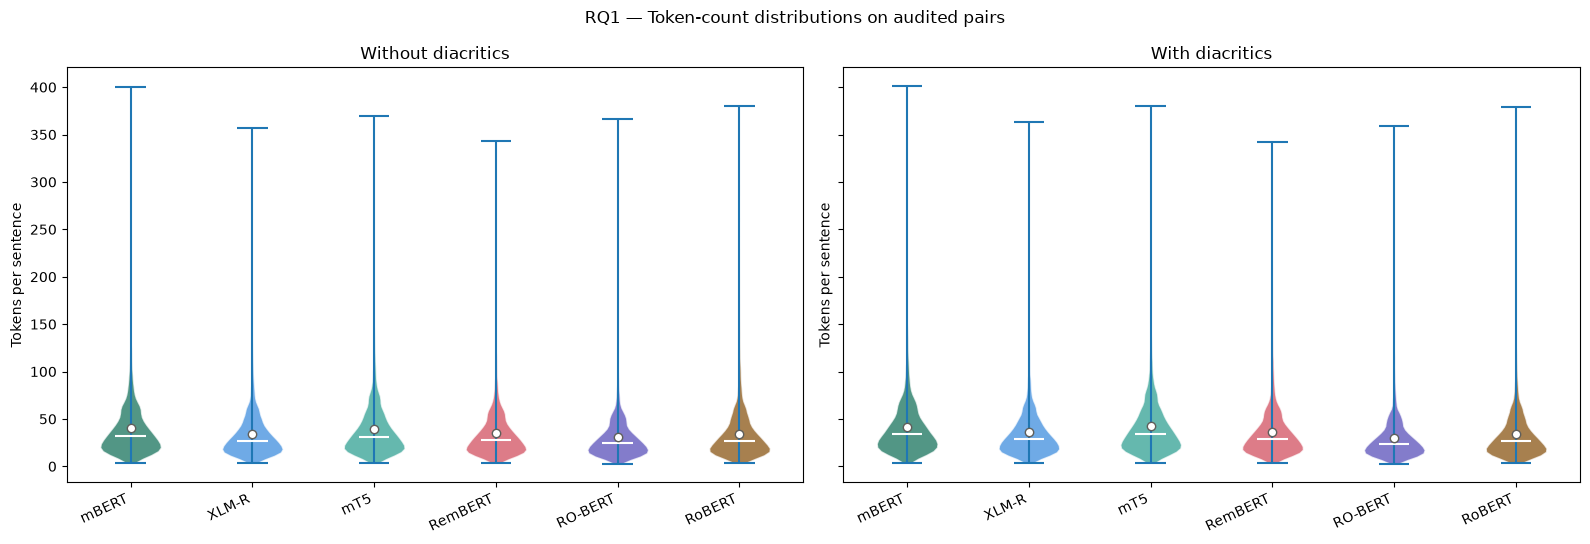

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, column, title in [(axes[0], "tokens_nd", "Without diacritics"), (axes[1], "tokens_d", "With diacritics")]:
    values = [df.loc[df["model"] == m, column].dropna().values for m in MODEL_ORDER]
    parts = ax.violinplot(values, positions=x, showmedians=True, showextrema=True)
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color); body.set_alpha(0.72); body.set_edgecolor("white")
    parts["cmedians"].set_color("white")
    ax.scatter(x, [np.mean(v) for v in values], c="white", edgecolors="#5F5E5A", zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_title(title); ax.set_ylabel("Tokens per sentence")
fig.suptitle("RQ1 — Token-count distributions on audited pairs")
plt.tight_layout(); plt.savefig(FIG_DIR / "rq1_fig1_token_distributions.png", dpi=180, bbox_inches="tight"); plt.show()


## Figure 2 — Fertility


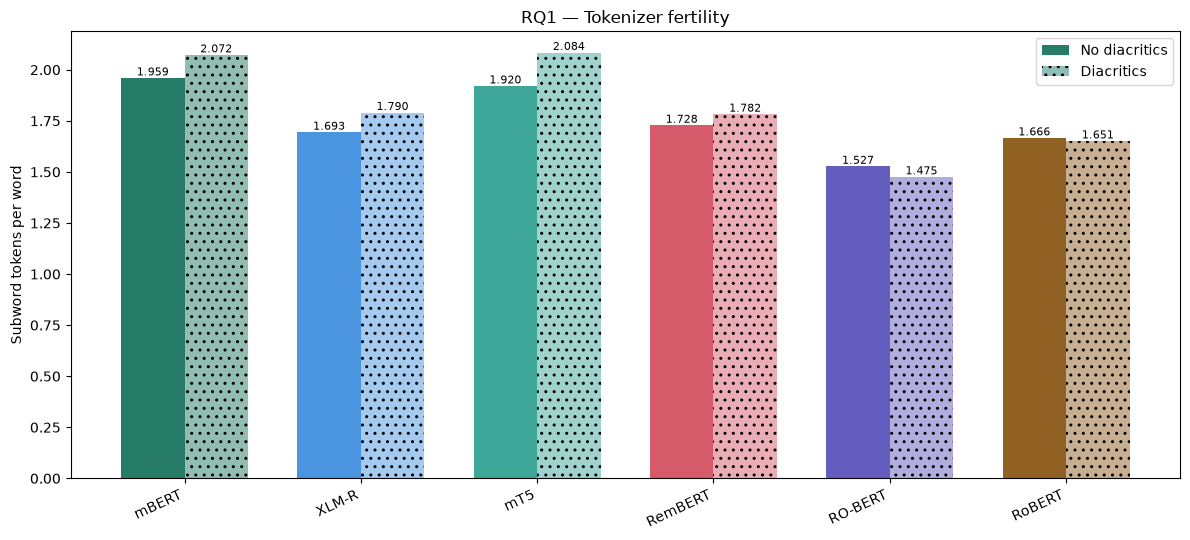

In [3]:
fig, ax = plt.subplots(figsize=(12, 5.5))
b1=ax.bar(x-w/2,ordered["avg_fert_nd"],w,color=colors,alpha=.9,label="No diacritics")
b2=ax.bar(x+w/2,ordered["avg_fert_d"],w,color=colors,alpha=.45,hatch="..",label="Diacritics")
ax.bar_label(b1,fmt="%.3f",fontsize=8); ax.bar_label(b2,fmt="%.3f",fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels,rotation=25,ha="right")
ax.set_ylabel("Subword tokens per word"); ax.set_title("RQ1 — Tokenizer fertility"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "rq1_fig2_fertility.png",dpi=180,bbox_inches="tight"); plt.show()


## Figure 3 — Token inflation


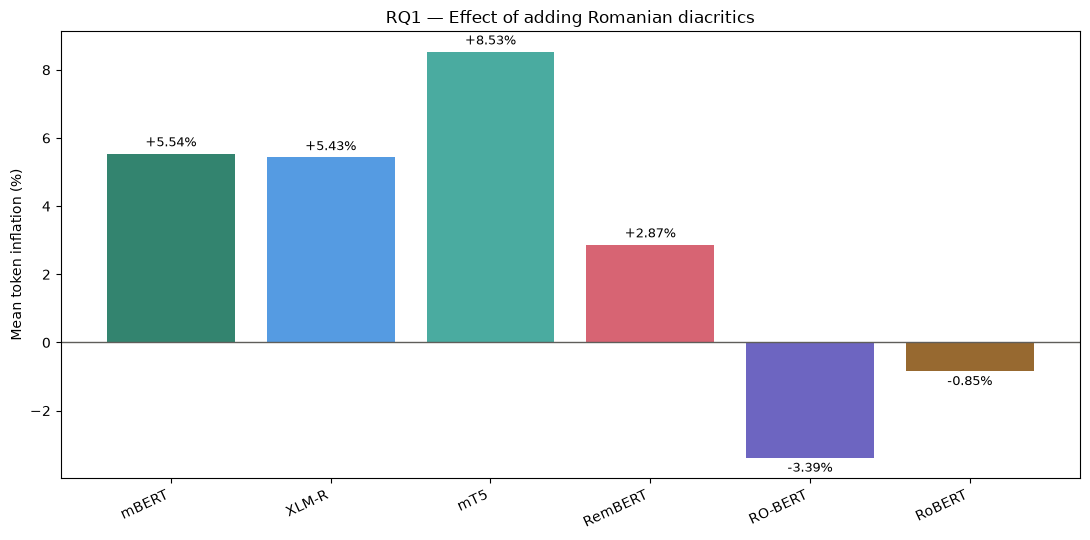

In [4]:
inflation=ordered["avg_inflation"].to_numpy()*100
fig,ax=plt.subplots(figsize=(11,5.5)); bars=ax.bar(x,inflation,color=colors,alpha=.85)
ax.axhline(0,color="#5F5E5A",linewidth=1); ax.bar_label(bars,labels=[f"{v:+.2f}%" for v in inflation],padding=3,fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels,rotation=25,ha="right")
ax.set_ylabel("Mean token inflation (%)"); ax.set_title("RQ1 — Effect of adding Romanian diacritics")
plt.tight_layout(); plt.savefig(FIG_DIR / "rq1_fig3_token_inflation.png",dpi=180,bbox_inches="tight"); plt.show()


## Figure 4 — UNK and single-character rate


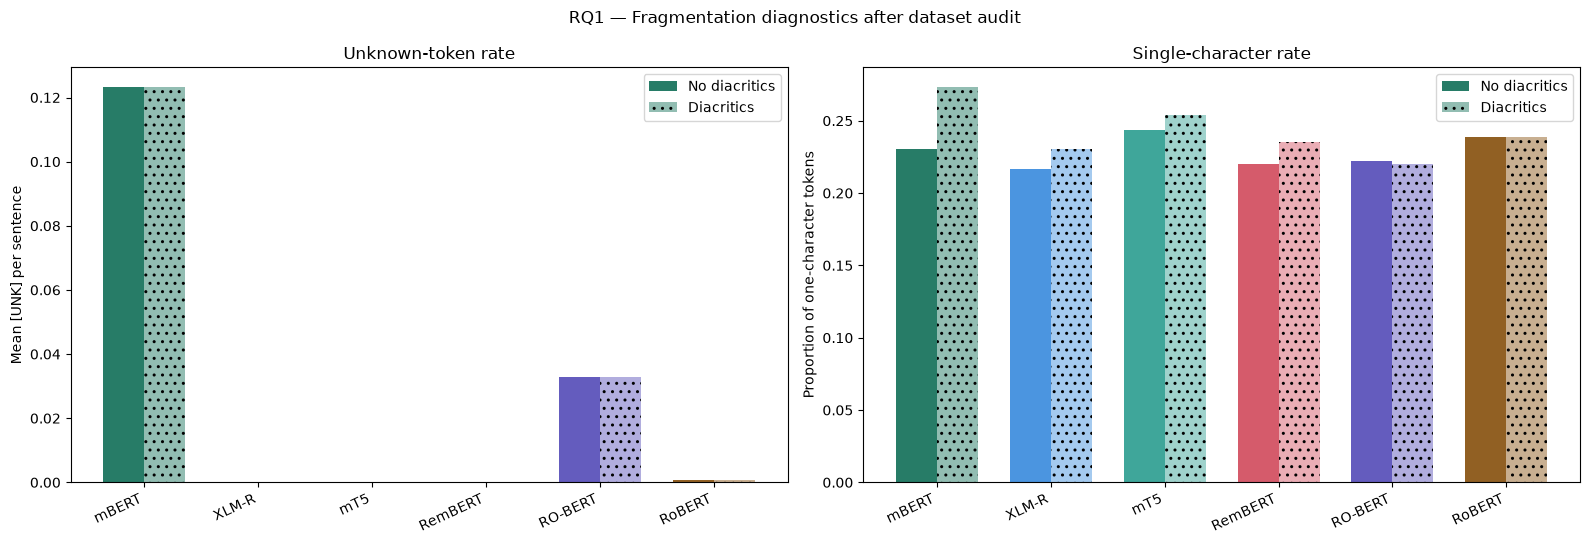

In [5]:
fig,axes=plt.subplots(1,2,figsize=(16,5.5))
for ax,nd_col,d_col,title,ylabel in [
    (axes[0],"avg_unk_nd","avg_unk_d","Unknown-token rate","Mean [UNK] per sentence"),
    (axes[1],"avg_scr_nd","avg_scr_d","Single-character rate","Proportion of one-character tokens"),
]:
    ax.bar(x-w/2,ordered[nd_col],w,color=colors,alpha=.9,label="No diacritics")
    ax.bar(x+w/2,ordered[d_col],w,color=colors,alpha=.45,hatch="..",label="Diacritics")
    ax.set_xticks(x); ax.set_xticklabels(labels,rotation=25,ha="right"); ax.set_title(title); ax.set_ylabel(ylabel); ax.legend()
fig.suptitle("RQ1 — Fragmentation diagnostics after dataset audit")
plt.tight_layout(); plt.savefig(FIG_DIR / "rq1_fig4_unk_scr.png",dpi=180,bbox_inches="tight"); plt.show()


## Figure 5 — Vocabulary overlap


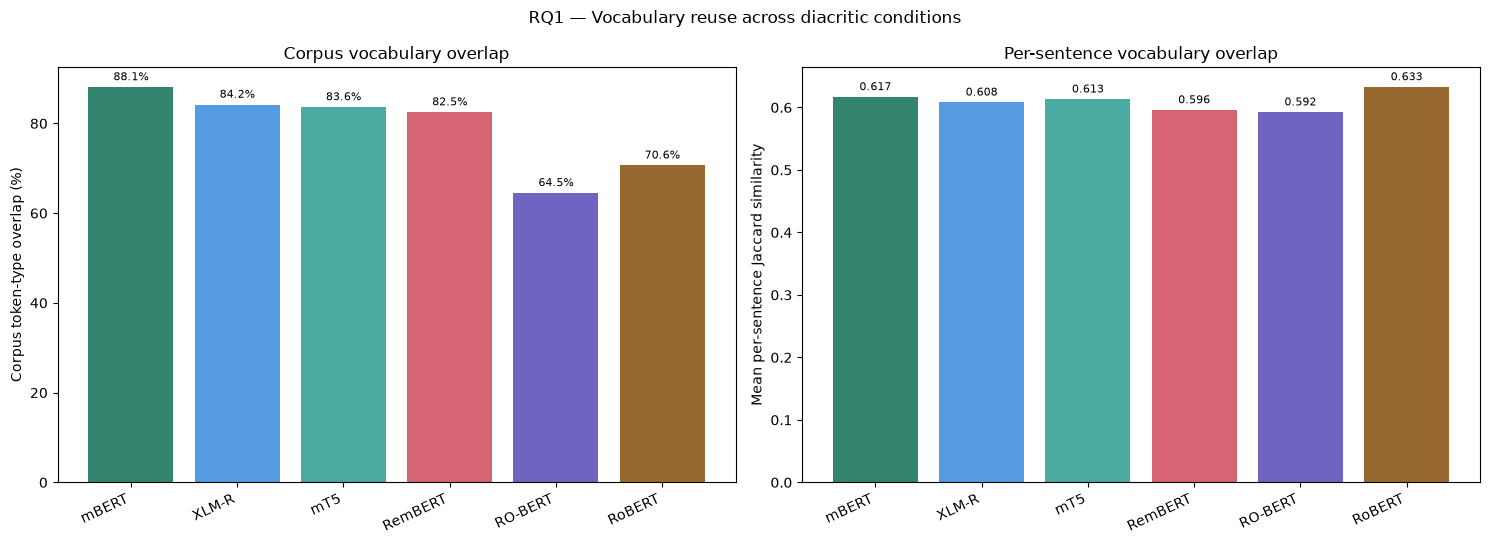

In [6]:
vocab_all=vocab_df[vocab_df["source"].astype(str).str.upper()=="ALL"].set_index("model").loc[MODEL_ORDER]
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
b=axes[0].bar(x,vocab_all["overlap_pct"],color=colors,alpha=.85); axes[0].bar_label(b,labels=[f"{v:.1f}%" for v in vocab_all["overlap_pct"]],padding=3,fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels,rotation=25,ha="right"); axes[0].set_ylabel("Corpus token-type overlap (%)"); axes[0].set_title("Corpus vocabulary overlap")
b=axes[1].bar(x,vocab_all["mean_jaccard"],color=colors,alpha=.85); axes[1].bar_label(b,fmt="%.3f",padding=3,fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels,rotation=25,ha="right"); axes[1].set_ylabel("Mean per-sentence Jaccard similarity"); axes[1].set_title("Per-sentence vocabulary overlap")
fig.suptitle("RQ1 — Vocabulary reuse across diacritic conditions")
plt.tight_layout(); plt.savefig(FIG_DIR / "rq1_fig5_vocab_overlap.png",dpi=180,bbox_inches="tight"); plt.show()


## Figure 6 — Source-stratified appendix plot


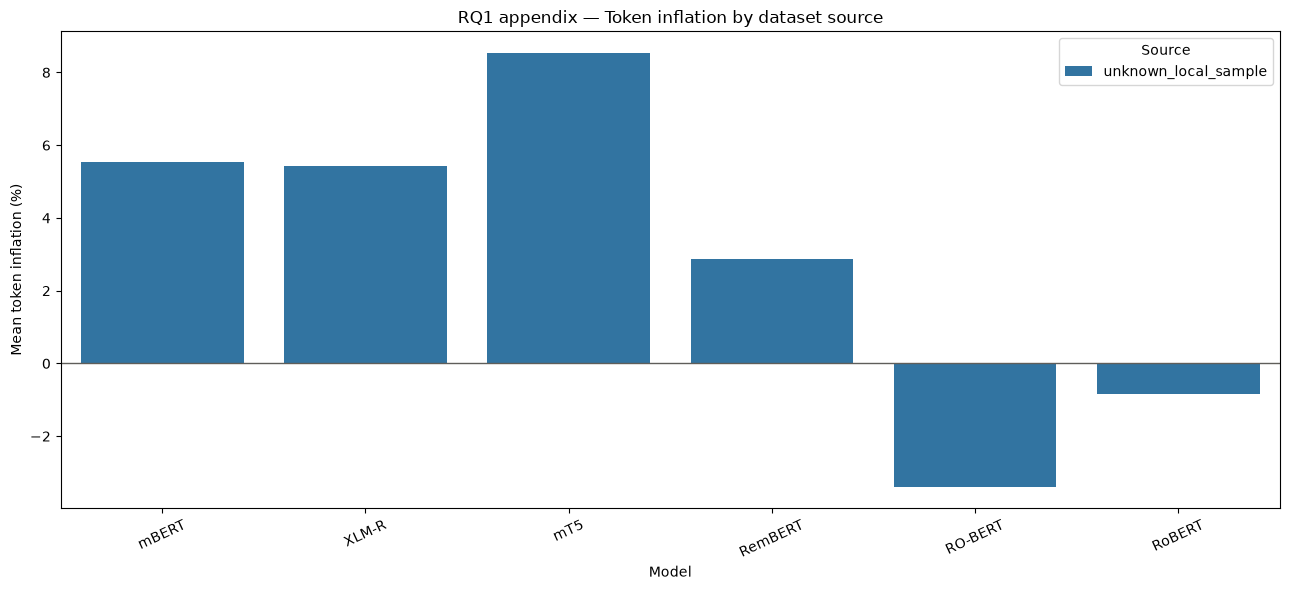

In [7]:
source_plot=summary_by_source.copy(); source_plot["inflation_pct"]=source_plot["avg_inflation"]*100
fig,ax=plt.subplots(figsize=(13,6)); sns.barplot(data=source_plot,x="display",y="inflation_pct",hue="source",order=labels,ax=ax)
ax.axhline(0,color="#5F5E5A",linewidth=1); ax.set_xlabel("Model"); ax.set_ylabel("Mean token inflation (%)")
ax.set_title("RQ1 appendix — Token inflation by dataset source"); ax.tick_params(axis="x",rotation=25); ax.legend(title="Source")
plt.tight_layout(); plt.savefig(FIG_DIR / "rq1_fig6_inflation_by_source.png",dpi=180,bbox_inches="tight"); plt.show()


## Output verification


In [8]:
created=sorted(FIG_DIR.glob("rq1_*.png"))
print(f"Created {len(created)} figures in {FIG_DIR.resolve()}")
for path in created:
    print(f"- {path.name} ({path.stat().st_size/1024:.1f} KB)")
assert len(created)==6, f"Expected 6 plots, found {len(created)}"


Created 6 figures in C:\Cristina\LLMs-handling-Romanian-Diacritics\RoDi\backup\figures_rq1_from_saved_outputs
- rq1_fig1_token_distributions.png (130.3 KB)
- rq1_fig2_fertility.png (110.2 KB)
- rq1_fig3_token_inflation.png (55.9 KB)
- rq1_fig4_unk_scr.png (139.4 KB)
- rq1_fig5_vocab_overlap.png (107.7 KB)
- rq1_fig6_inflation_by_source.png (57.0 KB)
